In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [17]:
csv_path = "mnist_test_nolabels.csv" # change if needed
random_state = 42
max_pc_bars = 50 # how many PCs to show as bars (for readability)
pca_for_tsne_n_components = 50 # reduce with PCA before t-SNE (speed & noise reduction)
tsne_perplexity = 30
tsne_n_iter = 500

## PCA Program Starting Here!

In [18]:

def train_and_evaluate_with_pca(X):
    # Ensure X only contains the features you want to analyze with PCA
    # Step 1: Standardize the data
    # PCA is affected by scale, so standardization (mean=0, variance=1) is crucial.
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_scaled = scaler.fit_transform(X)

    # Step 2: Perform PCA
    # We use all components initially to analyze total variance contribution
    pca = PCA(n_components=None, svd_solver='full', random_state=random_state)
    pca.fit(X_scaled)

    # Step 3: Extract explained variance ratios
    # The explained_variance_ratio_ attribute provides the percentage of variance 
    # explained by each individual principal component.
    explained_variance = pca.explained_variance_ratio_
    cum_var = np.cumsum(explained_variance)
    for i in range(min(10, len(explained_variance))):
        print(f"PC{i+1:3d}: explained variance ratio = {explained_variance[i]:.4f}, cumulative = {cum_var[i]:.4f}")
    # --- Plotting the Contributions (Bar Chart) ---
    for pct in [0.90, 0.95, 0.99]:
        k = np.searchsorted(cum_var, pct) + 1
        print(f"PCs needed to explain {int(pct*100)}% variance: {k}")
        
    # Create labels for the X-axis (PC1, PC2, PC3, ...)
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]


    plt.figure(figsize=(10, 5))
    n_bars = min(len(explained_variance), max_pc_bars)
    plt.bar(np.arange(1, n_bars+1), explained_variance[:n_bars], alpha=0.7)
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title(f"Explained Variance Ratio by Principal Component (first {n_bars})")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()
    

    # # Optional: Add cumulative variance line (scree plot element)
    cumulative_variance = np.cumsum(explained_variance) * 100
    plt.plot(pc_labels, cumulative_variance, color='red', linestyle='--', marker='o', label='Cumulative Variance (%)')
    plt.legend()
    plt.show()
    
    
    # Option A: color by KMeans clusters (useful when labels are not available)
    n_clusters = 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca.transform(X_scaled)[:, :2]) # use first two PCs for clustering

    plt.figure(figsize=(9,7))
    palette = sns.color_palette("tab10", n_clusters)
    for cl in range(n_clusters):
        idx = cluster_labels == cl
        plt.scatter(pca.transform(X_scaled)[:, :2][idx,0], pca.transform(X_scaled)[:, :2][idx,1], s=8, alpha=0.7, color=palette[cl], label=f'cluster {cl}')
    # optional: plot cluster centers
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:,0], centers[:,1], s=120, c='black', marker='X', edgecolor='white', linewidth=0.8)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PC1 vs PC2 colored by KMeans clusters')
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

    # --- Interpretation ---
    print("\nCumulative Variance Explained:")
    for i, cum_var in enumerate(cumulative_variance):
        print(f"PC{i+1}: {cum_var:.2f}%")
    mean_intensity = X.mean(axis=1)  
    # You can now select a subset of components (e.g., those explaining 95% variance)
    print('---------- Projection to first two PCs (for scatter) ----------')
    X_pca2 = pca.transform(X_scaled)[:, :2] # PC1 and PC2
    plt.figure(figsize=(8, 7))
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=mean_intensity, cmap='viridis', s=6, alpha=0.8)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Scatter plot: PC1 vs PC2")
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    return X_scaled

In [19]:
def pca_with_tsne(X_scaled, n_features):
    pca_pre = PCA(n_components=min(pca_for_tsne_n_components, n_features), random_state=random_state)
    X_pca_pre = pca_pre.fit_transform(X_scaled)

    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, max_iter=tsne_n_iter, random_state=random_state, init='pca')
    X_tsne = tsne.fit_transform(X_pca_pre)

    plt.figure(figsize=(8, 7))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=6, alpha=0.6)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(f"t-SNE (perplexity={tsne_perplexity}) scatter")
    plt.tight_layout()
    plt.show()

In [20]:
def pca_tsne_with_colored_clusters(X_scaled, n_features, n_clusters=10, pca_pre_components=50):
    """
    Pre-reduce with PCA, cluster the pre-reduced data with KMeans, run t-SNE on the same pre-reduced data,
    and plot the 2D t-SNE embedding colored by cluster labels (with cluster centers).
    """
    # PCA pre-reduction
    n_comp = min(pca_pre_components, n_features)
    pca_pre = PCA(n_components=n_comp, random_state=random_state)
    X_pca_pre = pca_pre.fit_transform(X_scaled)

    # KMeans clustering on PCA-reduced data
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca_pre)

    # t-SNE on PCA-reduced data (faster & less noisy)
    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, n_iter=tsne_n_iter, random_state=random_state, init='pca')
    X_tsne = tsne.fit_transform(X_pca_pre)

    # Plot t-SNE colored by cluster labels
    plt.figure(figsize=(9,7))
    # choose palette large enough
    max_palette = max(10, n_clusters)
    palette = sns.color_palette("tab20", max_palette)
    for cl in range(n_clusters):
        idx = cluster_labels == cl
        plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=8, alpha=0.75, color=palette[cl], label=f'cluster {cl}')
    # compute and plot cluster centers in t-SNE space
    centers_tsne = np.array([X_tsne[cluster_labels == cl].mean(axis=0) for cl in range(n_clusters)])
    plt.scatter(centers_tsne[:,0], centers_tsne[:,1], s=120, c='black', marker='X', edgecolor='white', linewidth=0.9, label='centers')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f't-SNE (pca_pre={n_comp}) colored by KMeans (k={n_clusters})')
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

    return X_tsne, cluster_labels

Data loaded: 9999 samples, 784 features
PC  1: explained variance ratio = 0.0620, cumulative = 0.0620
PC  2: explained variance ratio = 0.0424, cumulative = 0.1044
PC  3: explained variance ratio = 0.0404, cumulative = 0.1448
PC  4: explained variance ratio = 0.0323, cumulative = 0.1772
PC  5: explained variance ratio = 0.0276, cumulative = 0.2047
PC  6: explained variance ratio = 0.0241, cumulative = 0.2288
PC  7: explained variance ratio = 0.0205, cumulative = 0.2493
PC  8: explained variance ratio = 0.0188, cumulative = 0.2681
PC  9: explained variance ratio = 0.0167, cumulative = 0.2848
PC 10: explained variance ratio = 0.0152, cumulative = 0.3000
PCs needed to explain 90% variance: 193
PCs needed to explain 95% variance: 280
PCs needed to explain 99% variance: 486


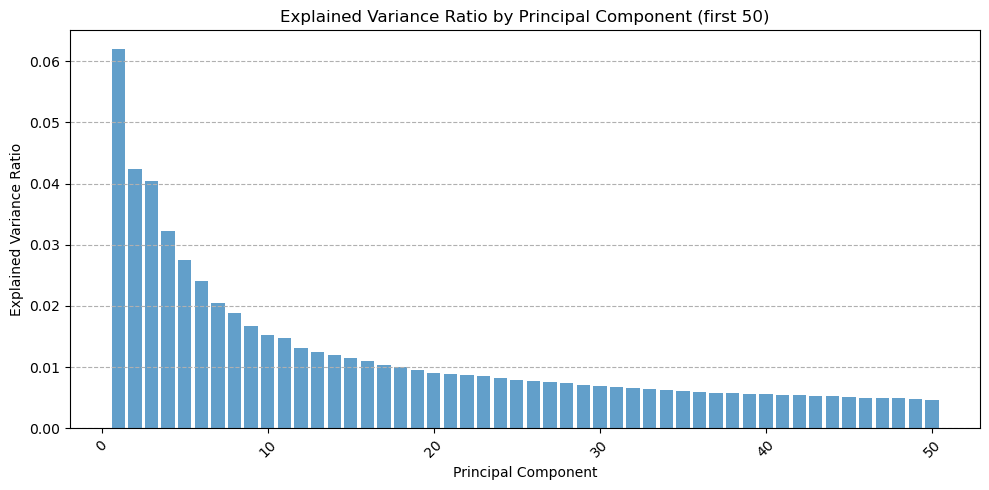

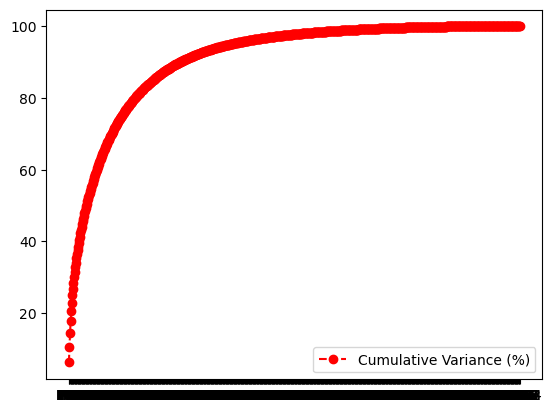

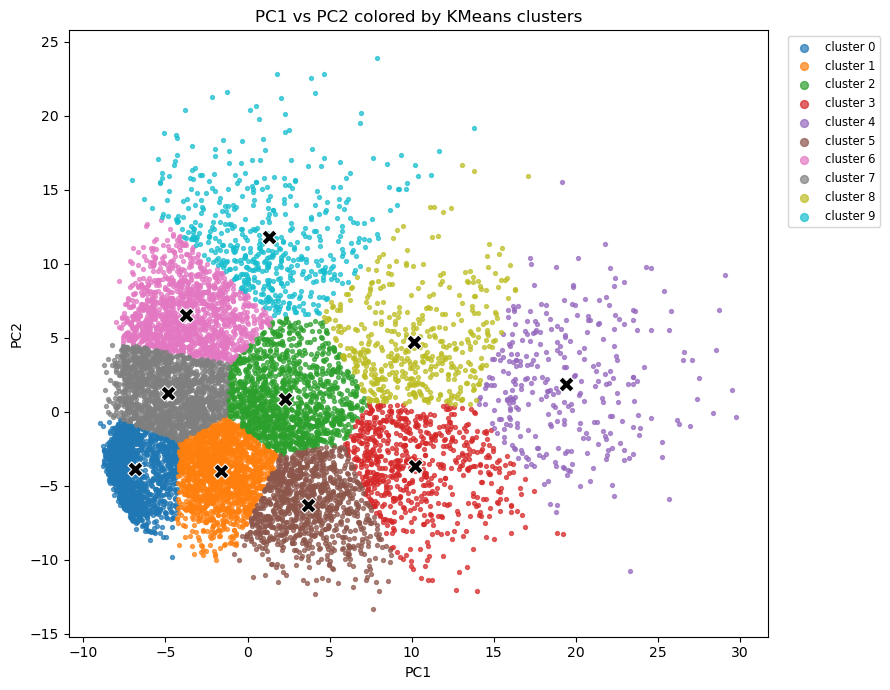


Cumulative Variance Explained:
PC1: 6.20%
PC2: 10.44%
PC3: 14.48%
PC4: 17.72%
PC5: 20.47%
PC6: 22.88%
PC7: 24.93%
PC8: 26.81%
PC9: 28.48%
PC10: 30.00%
PC11: 31.47%
PC12: 32.78%
PC13: 34.03%
PC14: 35.23%
PC15: 36.37%
PC16: 37.47%
PC17: 38.50%
PC18: 39.49%
PC19: 40.44%
PC20: 41.35%
PC21: 42.24%
PC22: 43.11%
PC23: 43.95%
PC24: 44.78%
PC25: 45.56%
PC26: 46.33%
PC27: 47.09%
PC28: 47.82%
PC29: 48.53%
PC30: 49.22%
PC31: 49.88%
PC32: 50.54%
PC33: 51.19%
PC34: 51.81%
PC35: 52.41%
PC36: 53.00%
PC37: 53.59%
PC38: 54.16%
PC39: 54.72%
PC40: 55.28%
PC41: 55.83%
PC42: 56.38%
PC43: 56.91%
PC44: 57.43%
PC45: 57.94%
PC46: 58.44%
PC47: 58.94%
PC48: 59.43%
PC49: 59.91%
PC50: 60.38%
PC51: 60.84%
PC52: 61.29%
PC53: 61.74%
PC54: 62.18%
PC55: 62.61%
PC56: 63.03%
PC57: 63.45%
PC58: 63.87%
PC59: 64.28%
PC60: 64.69%
PC61: 65.09%
PC62: 65.47%
PC63: 65.85%
PC64: 66.23%
PC65: 66.60%
PC66: 66.96%
PC67: 67.31%
PC68: 67.66%
PC69: 68.01%
PC70: 68.36%
PC71: 68.69%
PC72: 69.02%
PC73: 69.35%
PC74: 69.68%
PC75: 70.01%
PC7

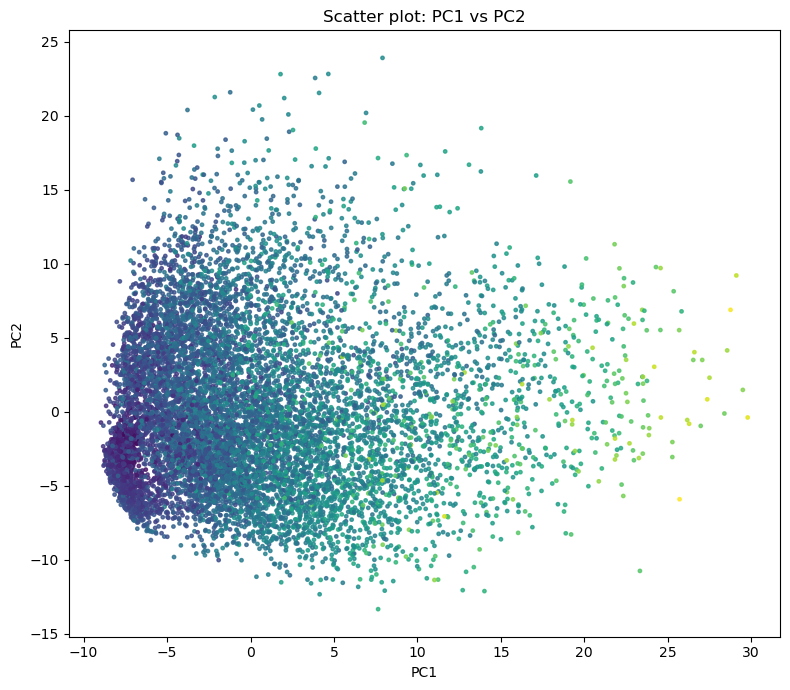

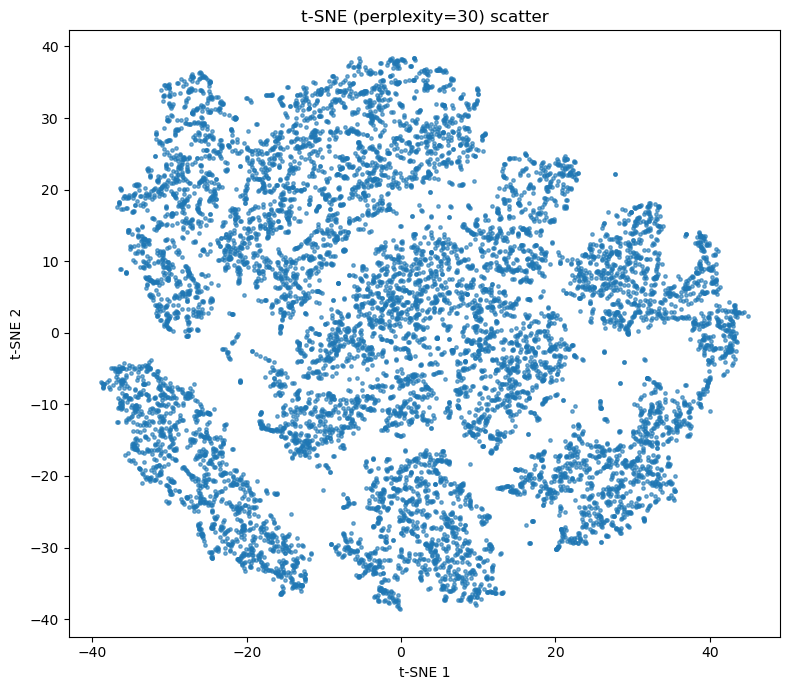

c:\Users\SUSHANT\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


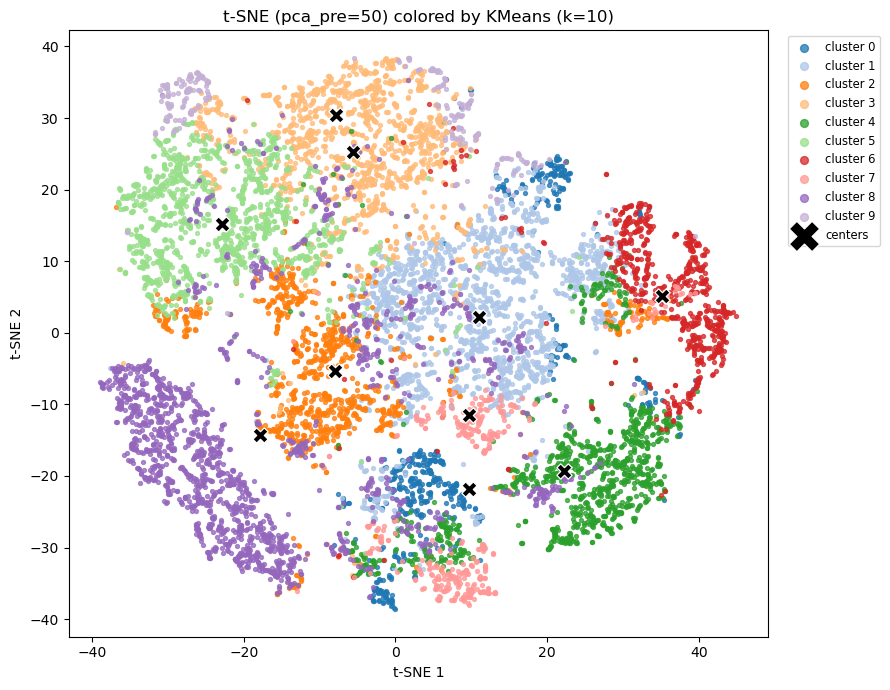

(array([[ -0.55014396, -38.198364  ],
        [-21.306293  , -21.177353  ],
        [ 28.36236   ,   6.939418  ],
        ...,
        [-15.09667   ,  10.577635  ],
        [-16.824726  , -13.5923815 ],
        [ 22.54151   , -29.252563  ]], shape=(9999, 2), dtype=float32),
 array([0, 8, 4, ..., 5, 2, 4], shape=(9999,), dtype=int32))

In [21]:
df = pd.read_csv(csv_path, header=1)
X = df.values.astype(float)
n_samples, n_features = X.shape
print(f"Data loaded: {n_samples} samples, {n_features} features")
X_scaled = train_and_evaluate_with_pca(X)
pca_with_tsne(X_scaled, n_features)
pca_tsne_with_colored_clusters(X_scaled, n_features, n_clusters=10, pca_pre_components=50)